# 빅데이터 처리와 시각화 9장 - 시각화 도구의 활용 Ⅰ: Matplotlib

이번 장에서는 파이썬 시각화의 **기반 라이브러리인 Matplotlib**을 집중 학습.

<div class="alert alert-block alert-info">
<b>💡 이번 장에서 배우는 것</b><br>
8장에서 분석한 데이터(매출, 고객, 시계열)를 그래프로 표현하는 방법을 배운다. 숫자만 가득한 DataFrame을 경영진도 바로 이해하는 차트로 바꾸는 것이 이번 장의 목표.
</div>

| 섹션 | 주제 | 핵심 함수 |
| :--- | :--- | :--- |
| 1 | Matplotlib 기초 구조 | `plt.subplots()`, `fig`, `ax` |
| 2 | 선 그래프 | `ax.plot()` — 시계열·추세 |
| 3 | 막대 그래프 | `ax.bar()`, `ax.barh()` — 범주형 비교 |
| 4 | 산점도 & 히스토그램 | `ax.scatter()`, `ax.hist()` — 분포·관계 |
| 5 | 서브플롯 & 스타일링 | `plt.subplots(m, n)` — 대시보드 구성 |
| 6 | Pandas `.plot()` 연동 | `df.plot()` — 원라인 시각화 |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정 (Mac: AppleGothic / Windows: Malgun Gothic)
import platform
if platform.system() == 'Darwin':       # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':    # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:                                   # Linux (Colab 등)
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False   # 마이너스(-) 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 100             # 화면 해상도

print(f'Matplotlib 버전: {mpl.__version__}')

Matplotlib 버전: 3.9.2


---
## 1. Matplotlib 기초 구조

Matplotlib의 핵심 개념은 **Figure(도화지)** 와 **Axes(그래프 영역)** 로 나뉜다.

```
Figure (전체 캔버스)
 └── Axes (그래프 영역 1개 이상)
       ├── Title, X·Y Label, Legend
       └── Plot (선, 막대, 점 ...)
```

<div class="alert alert-block alert-info">
<b>💡 plt vs ax — 어떤 걸 쓰나?</b><br>

| 방식 | 예시 | 언제? |
| :--- | :--- | :--- |
| `plt.xxx()` (pyplot API) | `plt.plot(x, y)` | 그래프 1개, 빠른 탐색용 |
| `ax.xxx()` (객체 API) | `ax.plot(x, y)` | 그래프 여러 개, 실무 권장 |

실무에서는 **항상 `fig, ax = plt.subplots()` 패턴**을 사용하는 것이 좋다.
</div>

#### 1-1. plt.subplots() 기본 패턴

```python
fig, ax = plt.subplots(figsize=(가로인치, 세로인치))

ax.plot(x, y)                    # 그래프 종류 선택
ax.set_title('제목')             # 제목
ax.set_xlabel('X축 이름')        # X축 레이블
ax.set_ylabel('Y축 이름')        # Y축 레이블
ax.legend()                      # 범례
ax.grid(True, alpha=0.3)         # 격자선

plt.tight_layout()               # 여백 자동 조정
plt.show()
```

| 파라미터 | 설명 | 예시 |
| :--- | :--- | :--- |
| `figsize` | 그래프 크기 (인치) | `(10, 4)` |
| `set_title` | 제목 | `fontsize=14` |
| `set_xlim` / `set_ylim` | 축 범위 고정 | `ax.set_ylim(0, 100)` |
| `tick_params` | 눈금 스타일 | `axis='x', rotation=45` |
| `grid` | 격자선 | `alpha=0.3, linestyle='--'` |

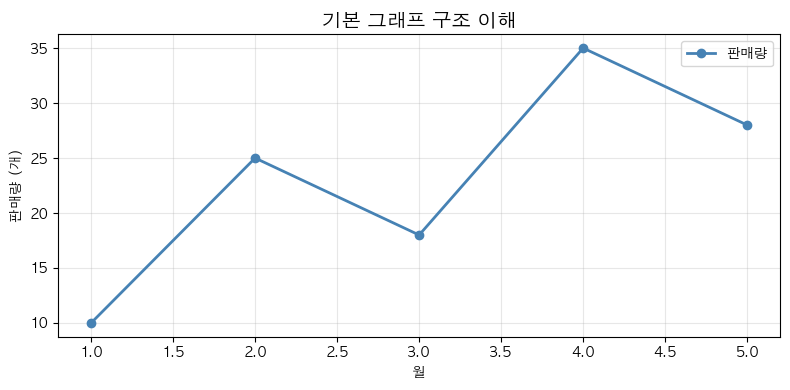

In [5]:
# Matplotlib 기본 구조 데모
x = [1, 2, 3, 4, 5]
y = [10, 25, 18, 35, 28]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y, color='steelblue', linewidth=2, marker='o', label='판매량')

ax.set_title('기본 그래프 구조 이해', fontsize=14, fontweight='bold')
ax.set_xlabel('월')
ax.set_ylabel('판매량 (개)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 1-2. 자주 쓰는 색상·선 스타일

| 파라미터 | 옵션 예시 | 설명 |
| :--- | :--- | :--- |
| `color` | `'steelblue'`, `'#E74C3C'`, `'tomato'` | 선/막대 색상 |
| `linestyle` (`ls`) | `'-'` 실선, `'--'` 점선, `':'` 점점 | 선 스타일 |
| `linewidth` (`lw`) | `1`, `2`, `3` | 선 두께 |
| `marker` | `'o'` 원, `'s'` 사각, `'^'` 삼각 | 데이터 포인트 모양 |
| `alpha` | `0.0 ~ 1.0` | 투명도 |
| `zorder` | 숫자가 클수록 위에 그려짐 | 레이어 순서 |

---
## 2. 선 그래프 (Line Plot)

- **언제 쓰나**: 시간 흐름에 따른 **추세(Trend)** 를 보여줄 때. 주가, 매출, 방문자 수 등.
- 이동평균선을 함께 그리면 노이즈를 제거하고 추세를 명확하게 할 수 있음.

8장에서 만든 일별 쇼핑몰 매출 데이터(`df_ts`)를 그대로 활용.

In [8]:
# 8장 시계열 데이터 재생성 (동일한 seed)
np.random.seed(0)
dates = pd.date_range(start='2024-01-01', end='2024-03-31', freq='D')
trend = np.linspace(500000, 800000, len(dates))
weekday_effect = np.where(pd.Series(dates).dt.dayofweek >= 5, 1.3, 1.0)
noise = np.random.normal(0, 50000, len(dates))

df_ts = pd.DataFrame({
    '날짜': dates,
    '일별매출': (trend * weekday_effect + noise).astype(int),
    '방문자수': np.random.normal(1500, 200, len(dates)).astype(int)
}).set_index('날짜')

df_ts['MA_7일']  = df_ts['일별매출'].rolling(window=7).mean().round(0)
df_ts['MA_14일'] = df_ts['일별매출'].rolling(window=14).mean().round(0)

print(f'데이터 기간: {df_ts.index[0].date()} ~ {df_ts.index[-1].date()}')
display(df_ts.head(5))

데이터 기간: 2024-01-01 ~ 2024-03-31


,일별매출,방문자수,MA_7일,MA_14일
날짜,,,,
2024-01-01,588202,1744,NaN,NaN
2024-01-02,523341,1541,NaN,NaN
2024-01-03,555603,1695,NaN,NaN
2024-01-04,622044,1571,NaN,NaN
2024-01-05,606711,1641,NaN,NaN


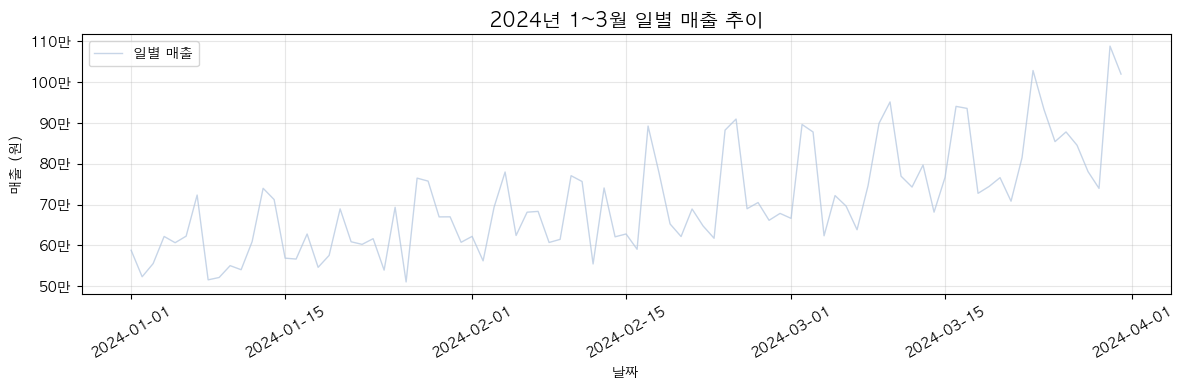

In [9]:
# 기본 선 그래프: 일별 매출 추세
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df_ts.index, df_ts['일별매출'],
        color='lightsteelblue', lw=1, alpha=0.7, label='일별 매출')

ax.set_title('2024년 1~3월 일별 매출 추이', fontsize=14, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('매출 (원)')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

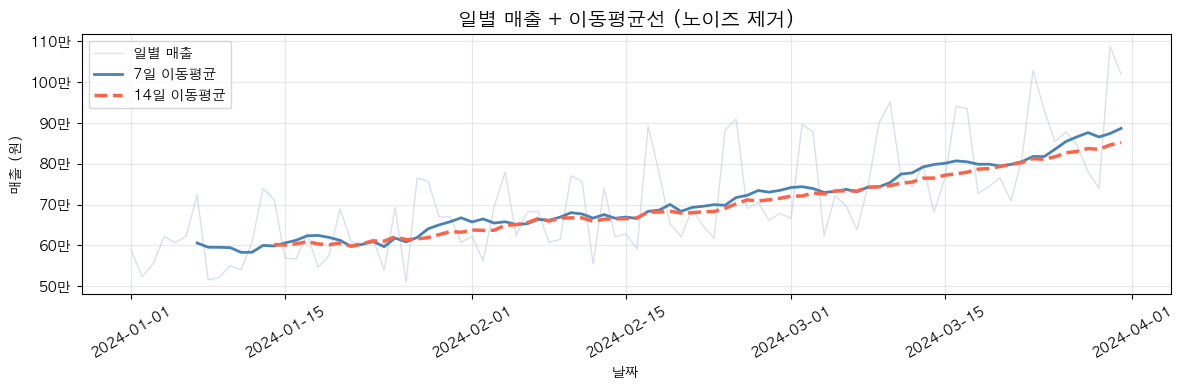

In [10]:
# 이동평균선 오버레이 — 노이즈 제거, 추세 강조
fig, ax = plt.subplots(figsize=(12, 4))

# 원본 데이터: 연하게
ax.plot(df_ts.index, df_ts['일별매출'],
        color='lightsteelblue', lw=1, alpha=0.5, label='일별 매출')

# 7일 이동평균: 중간 강조
ax.plot(df_ts.index, df_ts['MA_7일'],
        color='steelblue', lw=2, label='7일 이동평균')

# 14일 이동평균: 진하게 (추세선)
ax.plot(df_ts.index, df_ts['MA_14일'],
        color='tomato', lw=2.5, ls='--', label='14일 이동평균')

ax.set_title('일별 매출 + 이동평균선 (노이즈 제거)', fontsize=14, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('매출 (원)')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

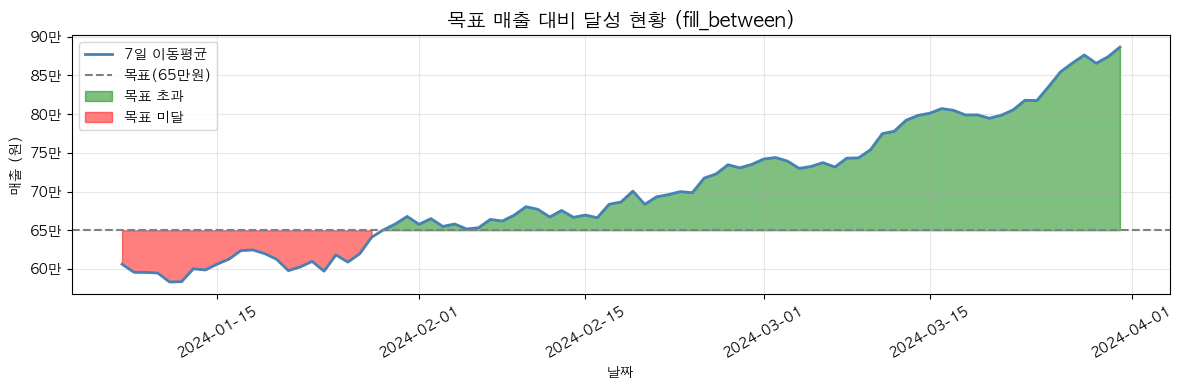

In [11]:
# fill_between: 목표 매출 대비 초과/미달 구역 음영 처리
target = 650000   # 목표 매출

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df_ts.index, df_ts['MA_7일'], color='steelblue', lw=2, label='7일 이동평균')
ax.axhline(target, color='gray', lw=1.5, ls='--', label=f'목표({target/10000:.0f}만원)')

# 목표 초과 구간: 초록
ax.fill_between(df_ts.index, df_ts['MA_7일'], target,
                where=(df_ts['MA_7일'] >= target),
                alpha=0.5, color='green', label='목표 초과')

# 목표 미달 구간: 빨강
ax.fill_between(df_ts.index, df_ts['MA_7일'], target,
                where=(df_ts['MA_7일'] < target),
                alpha=0.5, color='red', label='목표 미달')

ax.set_title('목표 매출 대비 달성 현황 (fill_between)', fontsize=14, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('매출 (원)')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> #### Exercise
> 위의 `df_ts` 데이터를 활용하여 다음을 수행하시오.
> 1. **방문자수**의 일별 추이를 선 그래프로 그리시오. (제목·축 레이블·격자선 필수)
> 2. 방문자수의 **7일 이동평균**을 같은 그래프에 빨간 점선으로 추가하시오.
> 3. Y축 숫자를 `1,500` 처럼 **천 단위 콤마**로 표시하시오.
>    (힌트: `ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))`)

In [13]:
# 여기에 코드를 작성하시오.


---
## 3. 막대 그래프 (Bar Chart)

- **언제 쓰나**: **범주별 크기 비교**. 지역별 매출, 카테고리별 건수 등.
- 막대 위에 숫자(annotate)를 추가하면 보고서용 차트로 바로 활용 가능.

| 함수 | 방향 | 적합한 상황 |
| :--- | :--- | :--- |
| `ax.bar(x, height)` | 수직 | 범주가 5개 이하, 크기 비교 |
| `ax.barh(y, width)` | 수평 | 범주 이름이 길 때, 순위 표현 |

In [15]:
# 8장 판매 데이터 재생성
np.random.seed(42)
data_sales = {
    '주문ID':   [f'ORD-{i:04d}' for i in range(1, 25)],
    '지역':     ['서울','서울','부산','부산','대구','서울','부산','대구',
                 '서울','서울','부산','서울','대구','부산','대구','서울',
                 '부산','서울','대구','서울','부산','대구','서울','부산'],
    '카테고리':  ['전자제품','의류','전자제품','식품','의류','식품','전자제품','의류',
                 '식품','전자제품','의류','전자제품','식품','전자제품','의류','식품',
                 '전자제품','의류','전자제품','식품','의류','전자제품','식품','의류'],
    '분기':     ['Q1','Q1','Q1','Q1','Q1','Q1','Q2','Q2',
                 'Q2','Q2','Q2','Q3','Q3','Q3','Q3','Q3',
                 'Q3','Q4','Q4','Q4','Q4','Q4','Q4','Q4'],
    '매출':     [1200000,85000,950000,42000,120000,55000,870000,95000,
                 38000,1100000,76000,980000,61000,1050000,88000,49000,
                 920000,105000,1300000,72000,91000,1150000,66000,83000],
    '수량':     [2,3,1,5,2,4,1,3,6,2,4,1,7,2,3,5,1,2,3,8,4,2,9,3]
}
df_sales = pd.DataFrame(data_sales)

# 지역별 총매출 집계
region_sales = df_sales.groupby('지역')['매출'].sum().sort_values(ascending=False)
print('지역별 총매출:')
print(region_sales)

지역별 총매출:
지역
부산    4082000
서울    3750000
대구    2814000
Name: 매출, dtype: int64


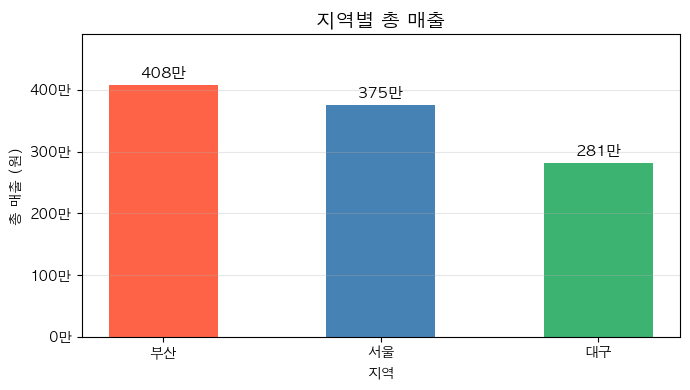

In [16]:
# 수직 막대 그래프 + 막대 위 숫자 표시
fig, ax = plt.subplots(figsize=(7, 4))

colors = ['tomato', 'steelblue', 'mediumseagreen']
bars = ax.bar(region_sales.index, region_sales.values, color=colors, width=0.5)

# 막대 위에 값 표시 (annotate)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height/10000:.0f}만',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=11, fontweight='bold')

ax.set_title('지역별 총 매출', fontsize=14, fontweight='bold')
ax.set_xlabel('지역')
ax.set_ylabel('총 매출 (원)')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
ax.set_ylim(0, region_sales.max() * 1.2)   # 숫자 레이블 공간 확보
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

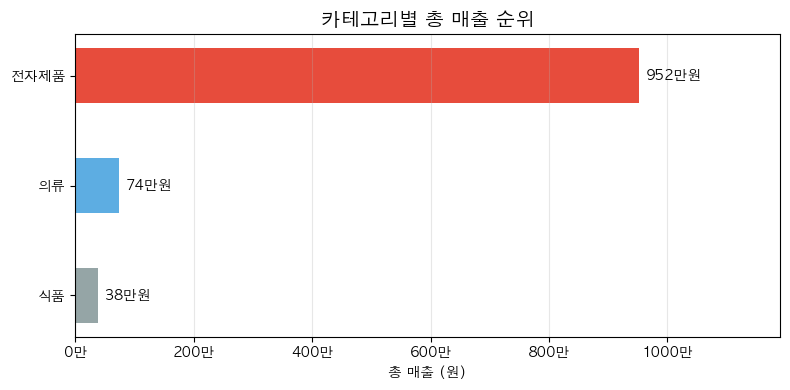

In [17]:
# 수평 막대 그래프: 카테고리별 매출 순위 (이름이 길 때 유용)
cat_sales = df_sales.groupby('카테고리')['매출'].sum().sort_values()  # 오름차순 → 위로 클수록 큼

fig, ax = plt.subplots(figsize=(8, 4))

colors_h = ['#95A5A6', '#5DADE2', '#E74C3C']
bars_h = ax.barh(cat_sales.index, cat_sales.values, color=colors_h, height=0.5)

# 막대 오른쪽에 값 표시
for bar in bars_h:
    width = bar.get_width()
    ax.annotate(f'{width/10000:.0f}만원',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords='offset points',
                va='center', fontsize=10)

ax.set_title('카테고리별 총 매출 순위', fontsize=14, fontweight='bold')
ax.set_xlabel('총 매출 (원)')
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
ax.set_xlim(0, cat_sales.max() * 1.25)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

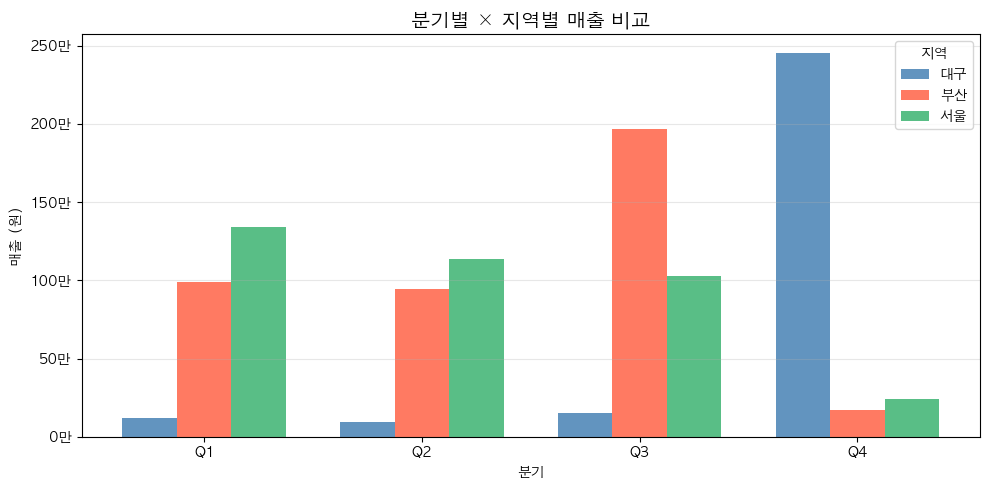

In [18]:
# 그룹 막대 그래프: 분기별 × 지역별 매출 비교
pivot_q = df_sales.pivot_table(values='매출', index='분기', columns='지역', aggfunc='sum', fill_value=0)

x = np.arange(len(pivot_q.index))  # 분기 위치
width = 0.25                        # 막대 너비
regions = pivot_q.columns.tolist()
colors_g = ['steelblue', 'tomato', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(10, 5))

for i, (region, color) in enumerate(zip(regions, colors_g)):
    offset = (i - 1) * width           # -1, 0, +1 위치 이동
    ax.bar(x + offset, pivot_q[region], width, label=region, color=color, alpha=0.85)

ax.set_title('분기별 × 지역별 매출 비교', fontsize=14, fontweight='bold')
ax.set_xlabel('분기')
ax.set_ylabel('매출 (원)')
ax.set_xticks(x)
ax.set_xticklabels(pivot_q.index)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
ax.legend(title='지역')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

> #### Exercise
> 위의 `df_sales` 데이터를 활용하여 다음을 수행하시오.
> 1. **카테고리별 평균 수량**을 수직 막대 그래프로 그리시오. 막대 위에 평균 수량을 소수점 1자리로 표시하시오.
> 2. **지역별 주문 건수**를 수평 막대 그래프로 그리되, 건수가 **많은 순서**부터 위에 오도록 정렬하시오.
> 3. 분기별 총 매출을 **누적 막대 그래프**로 그리시오.
>    (힌트: `ax.bar(x, 대구값, label='대구')`, `ax.bar(x, 부산값, bottom=대구값, label='부산')` 처럼 `bottom` 파라미터 활용)

In [20]:
# 여기에 코드를 작성하시오.


> #### Advance
> - `df_sales`의 분기별 × 카테고리별 매출 피벗 테이블을 만들고,
> - 이를 **누적 막대 그래프**로 시각화하되 각 막대 안에 카테고리 이름과 금액을 함께 표시하시오.
> - 예시: 막대 중간에 `'전자제품\n952만'` 텍스트가 들어가는 형태

In [22]:
# 여기에 코드를 작성하시오.


---
## 4. 산점도 & 히스토그램

### 4-1. 산점도 (Scatter Plot)
- **언제 쓰나**: **두 수치 변수의 관계(상관관계)** 를 확인할 때. 연간구매액 vs 구매횟수 등.
- `c` 파라미터로 색상에 제3의 변수를 매핑하면 3차원 관계까지 표현 가능.

In [24]:
# 8장 고객 데이터 재생성
data_customer = {
    '고객ID':    [f'C{i:03d}' for i in range(1, 16)],
    '나이':      [23, 35, 42, 28, 51, 19, 67, 31, 44, 56, 38, 25, 72, 48, 33],
    '연간구매액': [850000, 2300000, 1500000, 450000, 3800000, 120000, 5200000,
                  1800000, 2700000, 4100000, 950000, 330000, 6800000, 3200000, 1100000],
    '구매횟수':  [3, 12, 7, 2, 18, 1, 24, 9, 14, 20, 4, 2, 30, 15, 5]
}
df_cust = pd.DataFrame(data_customer)

bins_grade = [0, 500000, 1500000, 3000000, float('inf')]
labels_grade = ['일반', '실버', '골드', 'VIP']
df_cust['고객등급'] = pd.cut(df_cust['연간구매액'], bins=bins_grade, labels=labels_grade)

display(df_cust)

,고객ID,나이,연간구매액,구매횟수,고객등급
0,C001,23,850000,3,실버
1,C002,35,2300000,12,골드
2,C003,42,1500000,7,실버
3,C004,28,450000,2,일반
4,C005,51,3800000,18,VIP
5,C006,19,120000,1,일반
6,C007,67,5200000,24,VIP
7,C008,31,1800000,9,골드
8,C009,44,2700000,14,골드
9,C010,56,4100000,20,VIP


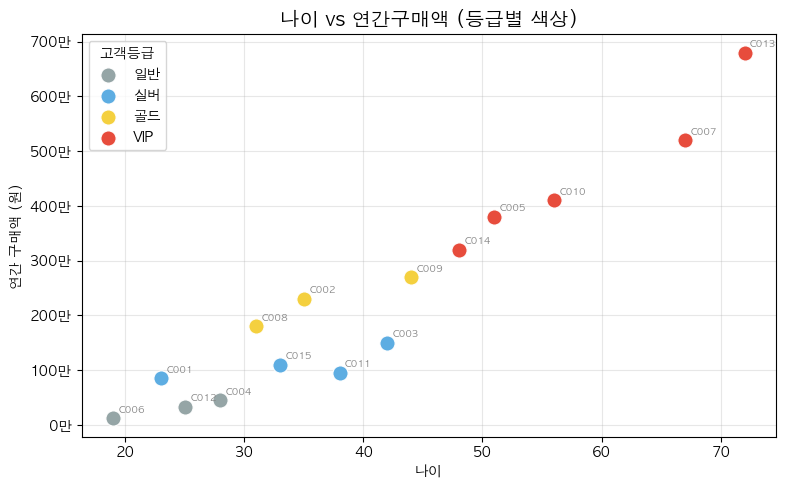

In [25]:
# 산점도: 나이 vs 연간구매액, 색상 = 고객등급
grade_colors = {'일반': '#95A5A6', '실버': '#5DADE2', '골드': '#F4D03F', 'VIP': '#E74C3C'}

fig, ax = plt.subplots(figsize=(8, 5))

for grade, group in df_cust.groupby('고객등급', observed=True):
    ax.scatter(group['나이'], group['연간구매액'],
               c=grade_colors[grade], s=120, label=grade,
               edgecolors='white', linewidths=0.8, zorder=3)

    # 고객 ID 라벨 추가
    for _, row in group.iterrows():
        ax.annotate(row['고객ID'],
                    xy=(row['나이'], row['연간구매액']),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=7, color='gray')

ax.set_title('나이 vs 연간구매액 (등급별 색상)', fontsize=14, fontweight='bold')
ax.set_xlabel('나이')
ax.set_ylabel('연간 구매액 (원)')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
ax.legend(title='고객등급')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4-2. 히스토그램 (Histogram)
- **언제 쓰나**: **단일 수치 변수의 분포** 확인. 데이터가 어디에 몰려 있는지, 치우쳐 있는지 파악.
- `bins` 개수에 따라 모양이 달라지므로 여러 값으로 시도해 볼 것.

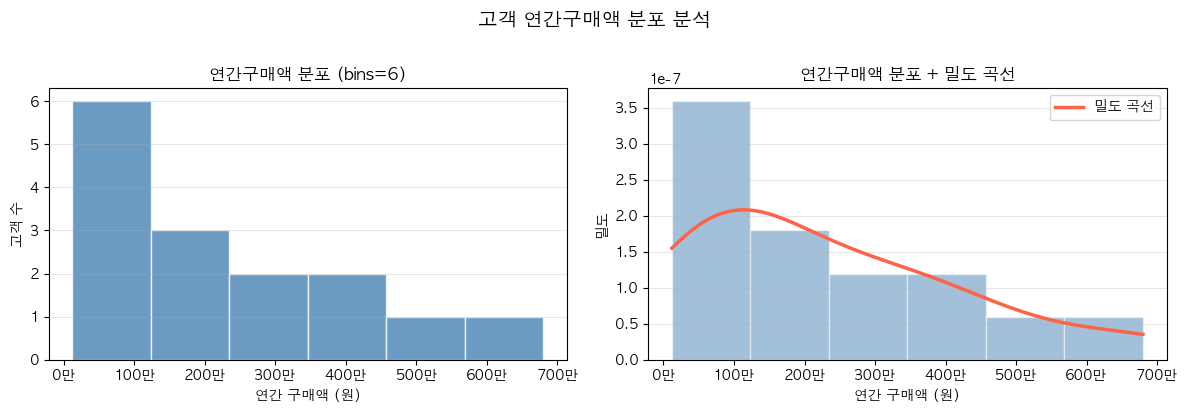

In [27]:
# 히스토그램: 연간구매액 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 기본 히스토그램
axes[0].hist(df_cust['연간구매액'], bins=6, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('연간구매액 분포 (bins=6)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('연간 구매액 (원)')
axes[0].set_ylabel('고객 수')
axes[0].xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 히스토그램 + KDE 곡선 (밀도)
from scipy.stats import gaussian_kde
data = df_cust['연간구매액'].values
kde = gaussian_kde(data, bw_method=0.5)
x_range = np.linspace(data.min(), data.max(), 200)

axes[1].hist(data, bins=6, color='steelblue', edgecolor='white', alpha=0.5, density=True)
axes[1].plot(x_range, kde(x_range), color='tomato', lw=2.5, label='밀도 곡선')
axes[1].set_title('연간구매액 분포 + 밀도 곡선', fontsize=12, fontweight='bold')
axes[1].set_xlabel('연간 구매액 (원)')
axes[1].set_ylabel('밀도')
axes[1].xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('고객 연간구매액 분포 분석', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> #### Exercise
> 위의 `df_cust` 데이터를 활용하여 다음을 수행하시오.
> 1. **구매횟수 vs 연간구매액** 산점도를 그리되, 점의 크기(`s`)를 나이에 비례하게 설정하시오. (`s=df_cust['나이'] * 5`)
> 2. **나이 분포**를 히스토그램(`bins=5`)으로 그리고, 각 막대 위에 해당 구간의 인원 수를 표시하시오.
> 3. 위 두 그래프를 `plt.subplots(1, 2, figsize=(12, 4))`로 나란히 배치하시오.

In [29]:
# 여기에 코드를 작성하시오.


---
## 5. 서브플롯 & 스타일링 — 실무 대시보드 구성

- 실무 보고서에서는 여러 그래프를 **한 Figure에 배치**하는 경우가 많음.
- `plt.subplots(rows, cols)`로 격자 배치, `plt.subplot_mosaic()`로 자유 배치가 가능.

```python
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2행 2열

ax1 = axes[0, 0]   # 1행 1열
ax2 = axes[0, 1]   # 1행 2열
ax3 = axes[1, 0]   # 2행 1열
ax4 = axes[1, 1]   # 2행 2열
```

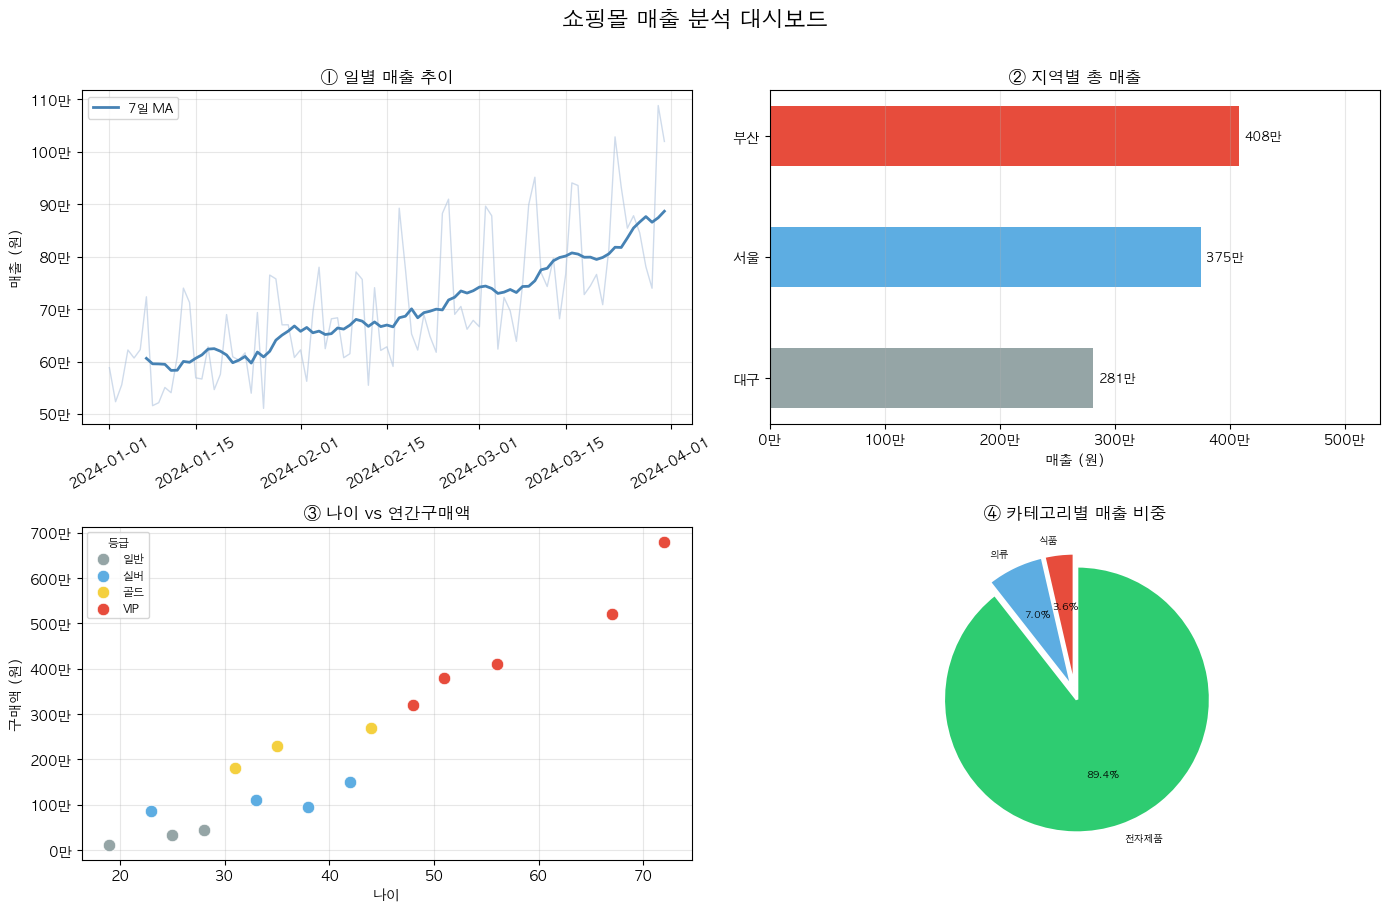

In [31]:
# 2×2 대시보드: 매출 분석 종합 리포트
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('쇼핑몰 매출 분석 대시보드', fontsize=16, fontweight='bold', y=1.01)

# ── [0,0] 일별 매출 추이 (선 그래프) ──────────────────
ax1 = axes[0, 0]
ax1.plot(df_ts.index, df_ts['일별매출'], color='lightsteelblue', lw=1, alpha=0.6)
ax1.plot(df_ts.index, df_ts['MA_7일'],  color='steelblue',      lw=2, label='7일 MA')
ax1.set_title('① 일별 매출 추이')
ax1.set_ylabel('매출 (원)')
ax1.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
ax1.tick_params(axis='x', rotation=30)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── [0,1] 지역별 총매출 (수평 막대) ───────────────────
ax2 = axes[0, 1]
region_s = df_sales.groupby('지역')['매출'].sum().sort_values()
colors2  = ['#95A5A6', '#5DADE2', '#E74C3C']
bars2 = ax2.barh(region_s.index, region_s.values, color=colors2, height=0.5)
for bar in bars2:
    w = bar.get_width()
    ax2.annotate(f'{w/10000:.0f}만', xy=(w, bar.get_y() + bar.get_height()/2),
                 xytext=(4, 0), textcoords='offset points', va='center', fontsize=9)
ax2.set_title('② 지역별 총 매출')
ax2.set_xlabel('매출 (원)')
ax2.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
ax2.set_xlim(0, region_s.max() * 1.3)
ax2.grid(axis='x', alpha=0.3)

# ── [1,0] 나이 vs 구매액 산점도 ──────────────────────
ax3 = axes[1, 0]
grade_c = {'일반':'#95A5A6','실버':'#5DADE2','골드':'#F4D03F','VIP':'#E74C3C'}
for grade, grp in df_cust.groupby('고객등급', observed=True):
    ax3.scatter(grp['나이'], grp['연간구매액'], c=grade_c[grade],
                s=80, label=grade, edgecolors='white', lw=0.5, zorder=3)
ax3.set_title('③ 나이 vs 연간구매액')
ax3.set_xlabel('나이')
ax3.set_ylabel('구매액 (원)')
ax3.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
ax3.legend(title='등급', fontsize=8, title_fontsize=8)
ax3.grid(True, alpha=0.3)

# ── [1,1] 카테고리별 매출 비중 파이 차트 ──────────────
ax4 = axes[1, 1]
cat_s = df_sales.groupby('카테고리')['매출'].sum()
explode = [0.05] * len(cat_s)
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
ax4.pie(cat_s.values, labels=cat_s.index, autopct='%1.1f%%',
        explode=explode, wedgeprops=wedge_props,
        colors=['#E74C3C','#5DADE2','#2ECC71'],
        startangle=90, textprops={'fontsize': 7})
ax4.set_title('④ 카테고리별 매출 비중')

plt.tight_layout()
plt.show()

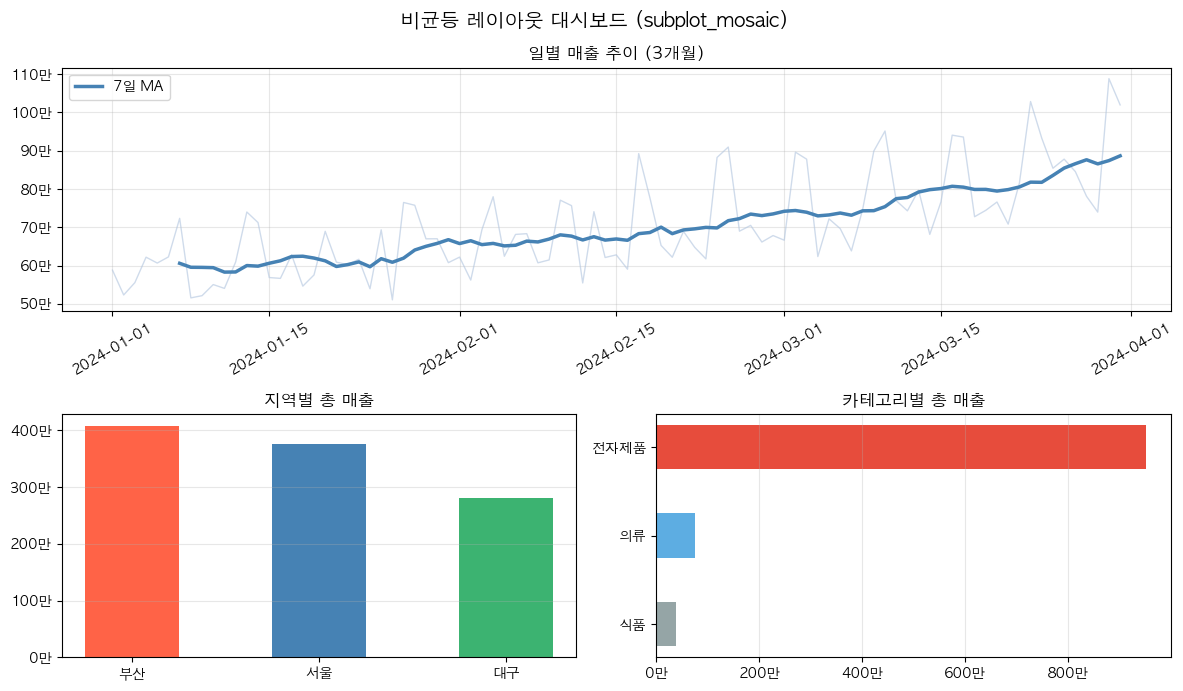

In [32]:
# subplot_mosaic: 비균등 레이아웃 (상단 와이드 + 하단 2개)
layout = [['top',  'top'],
          ['left', 'right']]

fig, axes = plt.subplot_mosaic(layout, figsize=(12, 7))
fig.suptitle('비균등 레이아웃 대시보드 (subplot_mosaic)', fontsize=14, fontweight='bold')

# 상단: 일별 매출 (넓은 칸)
axes['top'].plot(df_ts.index, df_ts['일별매출'], color='lightsteelblue', lw=1, alpha=0.6)
axes['top'].plot(df_ts.index, df_ts['MA_7일'],   color='steelblue', lw=2.5, label='7일 MA')
axes['top'].set_title('일별 매출 추이 (3개월)')
axes['top'].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes['top'].tick_params(axis='x', rotation=30)
axes['top'].legend()
axes['top'].grid(True, alpha=0.3)

# 하단 왼쪽: 지역별 매출 막대
region_s2 = df_sales.groupby('지역')['매출'].sum().sort_values(ascending=False)
axes['left'].bar(region_s2.index, region_s2.values,
                 color=['tomato','steelblue','mediumseagreen'], width=0.5)
axes['left'].set_title('지역별 총 매출')
axes['left'].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes['left'].grid(axis='y', alpha=0.3)

# 하단 오른쪽: 카테고리별 매출
cat_s2 = df_sales.groupby('카테고리')['매출'].sum().sort_values()
axes['right'].barh(cat_s2.index, cat_s2.values,
                   color=['#95A5A6','#5DADE2','#E74C3C'], height=0.5)
axes['right'].set_title('카테고리별 총 매출')
axes['right'].xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes['right'].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

> #### Exercise
> `plt.subplots(2, 2, figsize=(12, 8))`를 사용하여 아래 4개 그래프로 구성된 대시보드를 만드시오.
> 1. `[0,0]`: 분기별 총 매출 — 수직 막대 그래프
> 2. `[0,1]`: 고객 연간구매액 분포 — 히스토그램 (bins=5)
> 3. `[1,0]`: 나이 분포 — 히스토그램 (bins=5)
> 4. `[1,1]`: 구매횟수 vs 연간구매액 — 산점도
> - 각 그래프에 제목, 축 레이블을 반드시 추가하시오.
> - `plt.suptitle()`로 전체 제목을 추가하시오.

In [34]:
# 여기에 코드를 작성하시오.


---
## 6. Pandas `.plot()` 연동 — 원라인 시각화

- Pandas DataFrame/Series에는 내장 `.plot()` 메서드가 있어 Matplotlib 코드 없이 빠르게 그릴 수 있음.
- 내부적으로 Matplotlib을 사용하므로 이후 `ax` 객체로 추가 커스터마이징 가능.

```python
df.plot(kind='bar', figsize=(8, 4), title='제목')  # 기본 형태
```

| `kind` 값 | 그래프 종류 |
| :--- | :--- |
| `'line'` | 선 그래프 (기본값) |
| `'bar'` | 수직 막대 |
| `'barh'` | 수평 막대 |
| `'hist'` | 히스토그램 |
| `'scatter'` | 산점도 (`x=`, `y=` 필요) |
| `'pie'` | 파이 차트 |
| `'box'` | 박스플롯 |

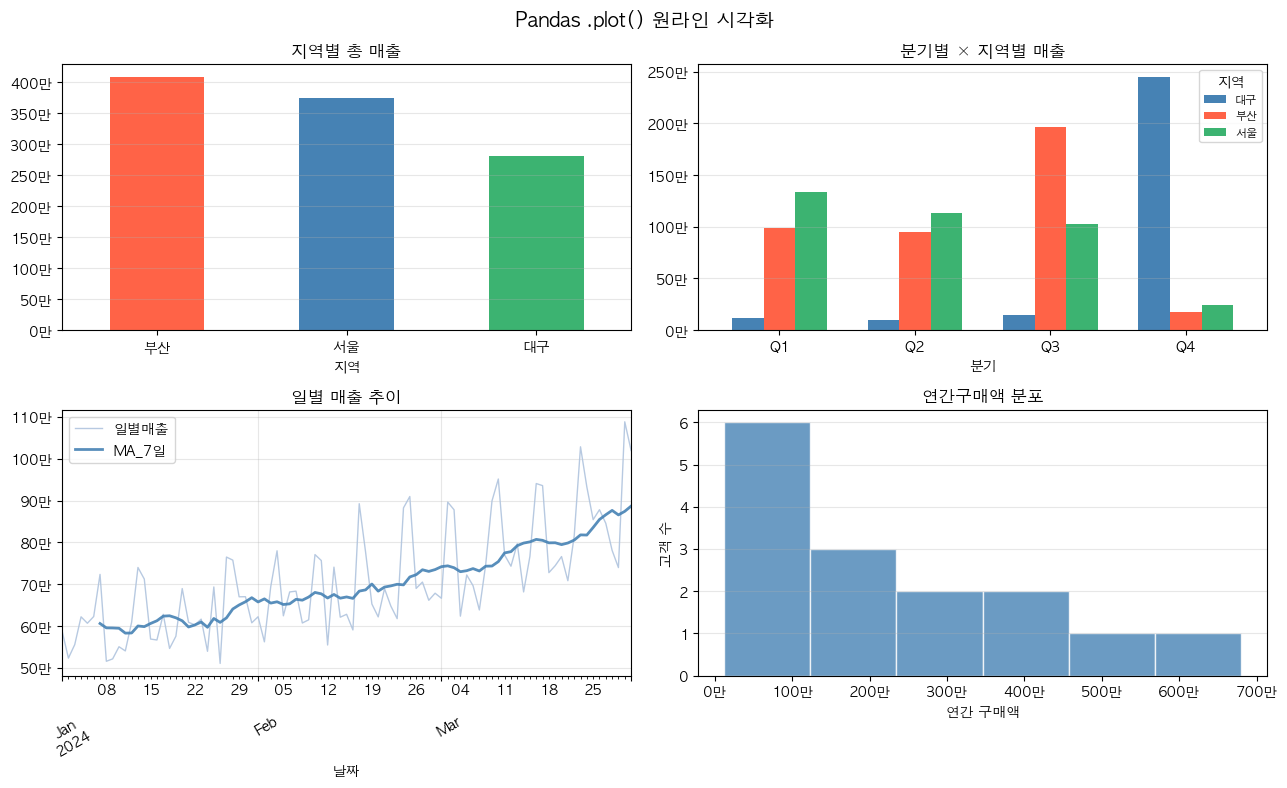

In [36]:
# Pandas .plot() 원라인 시각화 모음
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Pandas .plot() 원라인 시각화', fontsize=14, fontweight='bold')

# ① 지역별 총매출 — 수직 막대
region_s.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0,0], color=['tomato','steelblue','mediumseagreen'],
    title='지역별 총 매출', rot=0, width=0.5
)
axes[0,0].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes[0,0].grid(axis='y', alpha=0.3)

# ② 분기별 × 지역별 매출 — 그룹 막대 (DataFrame)
pivot_q.plot(
    kind='bar', ax=axes[0,1],
    title='분기별 × 지역별 매출', rot=0, width=0.7,
    color=['steelblue','tomato','mediumseagreen']
)
axes[0,1].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes[0,1].grid(axis='y', alpha=0.3)
axes[0,1].legend(title='지역', fontsize=8)

# ③ 일별 매출 + 7일 이동평균 — 선 그래프 (컬럼별 분리 호출)
df_ts['일별매출'].plot(ax=axes[1,0], color='lightsteelblue', lw=1, alpha=0.9, label='일별매출')
df_ts['MA_7일'].plot(ax=axes[1,0], color='steelblue',      lw=2, alpha=0.9, label='MA_7일')
axes[1,0].set_title('일별 매출 추이')
axes[1,0].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# ④ 연간구매액 분포 — 히스토그램
df_cust['연간구매액'].plot(
    kind='hist', ax=axes[1,1], bins=6,
    color='steelblue', edgecolor='white', alpha=0.8,
    title='연간구매액 분포'
)
axes[1,1].xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes[1,1].set_xlabel('연간 구매액')
axes[1,1].set_ylabel('고객 수')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

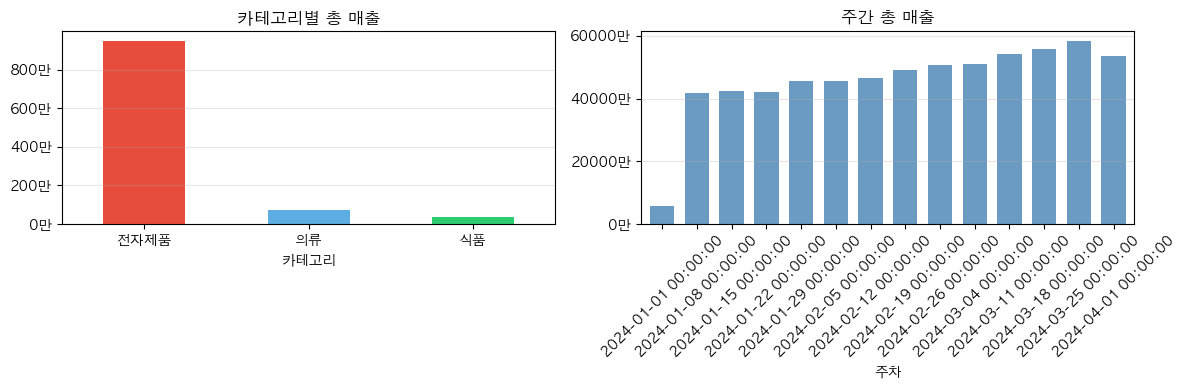

In [37]:
# groupby 결과를 바로 .plot()으로 시각화하는 실무 패턴
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 패턴 1: groupby → .plot(kind='bar')
(
    df_sales.groupby('카테고리')['매출']
    .sum()
    .sort_values(ascending=False)
    .plot(kind='bar', ax=axes[0], color=['#E74C3C','#5DADE2','#2ECC71'],
          title='카테고리별 총 매출', rot=0, width=0.5)
)
axes[0].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes[0].grid(axis='y', alpha=0.3)

# 패턴 2: resample → .plot(kind='line')
(
    df_ts['일별매출']
    .resample('W-MON')
    .sum()
    .plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8,
          title='주간 총 매출', rot=45, width=0.7)
)
axes[1].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/100:.0f}만'))
axes[1].set_xlabel('주차')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

> #### Exercise
> Pandas `.plot()`을 사용하여 다음 차트를 그리시오.
> 1. `df_sales`의 **분기별 총 매출**을 `kind='bar'`로 그리시오. 각 분기 막대의 색상을 각각 다르게 설정하시오.
> 2. `df_cust`의 **나이** 분포를 `kind='hist'`(bins=5)로 그리시오.
> 3. `df_ts`의 **월별 평균 매출**을 `resample('ME').mean()`으로 집계한 뒤 `kind='line'`, `marker='o'`로 그리시오.

In [39]:
# 여기에 코드를 작성하시오.


> #### Advance — 종합 실무 프로젝트
> 아래의 이커머스 300건 주문 데이터를 생성하고, 다음 4개 차트로 구성된 **경영진 보고용 대시보드**를 만드시오.
> 
> **요구사항**
> 1. `[0,0]` 월별 총매출 추이 — 선 그래프 + 전월 대비 성장률 표시 (텍스트 annotate)
> 2. `[0,1]` 카테고리별 매출 비중 — 파이 차트 (`autopct='%1.1f%%'`)
> 3. `[1,0]` 지역 × 카테고리 매출 히트맵 — `ax.imshow()` 또는 pivot 결과 텍스트 표시
> 4. `[1,1]` 고객 등급별 평균 구매액 — 수평 막대 그래프 (VIP → 일반 내림차순)
> 
> (힌트: 데이터 생성 코드는 8장 종합 실무 프로젝트 셀 참고)

In [41]:
# 이커머스 실습 데이터 생성 (8장과 동일)
np.random.seed(42)
n = 300

categories = ['전자제품', '의류/패션', '식품/음료', '생활용품', '스포츠']
regions    = ['서울', '경기', '부산', '대구', '인천']
price_by_cat = {
    '전자제품':  (200000, 1500000), '의류/패션': (20000, 200000),
    '식품/음료': (5000, 80000),     '생활용품':  (8000, 150000), '스포츠': (30000, 500000)
}

cat_list = np.random.choice(categories, size=n, p=[0.25, 0.3, 0.2, 0.15, 0.1])
prices   = np.array([np.random.randint(*price_by_cat[c]) for c in cat_list])
order_dates = pd.to_datetime(
    np.sort(pd.date_range('2024-01-01', periods=n, freq='D')
              .to_series().sample(n, replace=True).values))

df_ecom = pd.DataFrame({
    '주문일':   order_dates,
    '고객ID':   [f'CUS-{np.random.randint(1, 101):04d}' for _ in range(n)],
    '지역':     np.random.choice(regions, size=n, p=[0.35, 0.25, 0.15, 0.15, 0.1]),
    '카테고리': cat_list,
    '판매가':   prices,
    '수량':     np.random.randint(1, 5, size=n),
    '할인율(%)':np.random.choice([0, 5, 10, 15, 20], size=n, p=[0.4, 0.2, 0.2, 0.1, 0.1])
})
df_ecom['매출'] = (df_ecom['판매가'] * df_ecom['수량'] * (1 - df_ecom['할인율(%)'] / 100)).astype(int)

# 고객별 등급
cust_value = df_ecom.groupby('고객ID')['매출'].sum()
df_ecom['고객등급'] = df_ecom['고객ID'].map(
    pd.cut(cust_value, bins=[0,100000,500000,1500000,float('inf')],
           labels=['브론즈','실버','골드','VIP'])
)

print(f'데이터 크기: {df_ecom.shape}')
display(df_ecom.head(5))

# 여기에 대시보드 코드를 작성하시오.


데이터 크기: (300, 9)


,주문일,고객ID,지역,카테고리,판매가,수량,할인율(%),매출,고객등급
0,2024-01-01,CUS-0047,서울,의류/패션,183165,2,0,366330,VIP
1,2024-01-01,CUS-0068,경기,스포츠,492894,3,5,1404747,VIP
2,2024-01-01,CUS-0076,경기,식품/음료,44734,3,20,107361,VIP
3,2024-01-01,CUS-0045,부산,식품/음료,77615,2,0,155230,골드
4,2024-01-03,CUS-0002,인천,전자제품,273523,4,5,1039387,VIP


---
## 9장 핵심 정리

| 그래프 | 함수 | 언제? |
| :--- | :--- | :--- |
| 선 그래프 | `ax.plot()` | 시계열·추세·이동평균 |
| 면적 음영 | `ax.fill_between()` | 목표 대비 달성·미달 구간 |
| 수직 막대 | `ax.bar()` | 범주별 크기 비교 (5개 이하) |
| 수평 막대 | `ax.barh()` | 범주 이름이 길 때, 순위 |
| 산점도 | `ax.scatter()` | 두 수치 변수의 관계 |
| 히스토그램 | `ax.hist()` | 단일 수치 변수 분포 |
| 파이 차트 | `ax.pie()` | 비중·구성비 |
| 서브플롯 | `plt.subplots(m,n)` | 여러 그래프 동시 비교 |
| 비균등 레이아웃 | `plt.subplot_mosaic()` | 크기가 다른 패널 배치 |
| Pandas 통합 | `df.plot(kind=...)` | 빠른 탐색, 원라인 시각화 |

<div class="alert alert-block alert-success">
<b>실무 시각화 원칙</b><br>
① <b>목적에 맞는 차트</b>: 비교 → 막대, 추세 → 선, 분포 → 히스토그램, 관계 → 산점도<br>
② <b>데이터 잉크 최소화</b>: 불필요한 격자선·테두리·장식은 제거 (<code>alpha=0.3</code> 격자, <code>spines</code> 제거)<br>
③ <b>레이블 필수</b>: 제목, 축 이름, 단위(원, 명, %)는 항상 명시<br>
④ <b>색상은 의미 있게</b>: 빨강=위험/감소, 초록=달성/증가, 파랑=중립<br>
⑤ <b>fig, ax 패턴 고수</b>: <code>plt.subplots()</code>로 시작해야 여러 그래프 관리가 쉬움
</div>